In [1]:
from config import *

from Image_charge_3d import *

import scipy.integrate

In [2]:
class potential_due_sheet: 

    def __init__(self, d, charge_density, ep_qw = 11.7, ep_sige= 11.7, ep_ox=8, t_sige=10, t_ox=15):

        self.d = d   ## charge sheet is placed at a distance d 
        self.cd = charge_density 
        self.ep_qw = ep_qw
        self.ep_sige = ep_sige
        self.ep_ox= ep_ox
        self.t_sige = t_sige
        self.t_ox = t_ox

    def image_charge(self,  xp, yp):

        img_charge = Image_charge_calculator(q_ct=1, z_ct=self.d, y_ct = yp, x_ct= xp, ep_qw = self.ep_qw, ep_sige= self.ep_sige, ep_ox=self.ep_ox, t_sige=self.t_sige, t_ox=self.t_ox, r=1e-3).calc_image_charges()

        return img_charge


    def greens_function(self, x, y, z, xp, yp):

        #### please note, this is only the green's function part, no charge density invovled
        #### for Sheet of charge, charge density is constant. 
        #### Therefore a charge density prefactor(in C/nm^2) should be multiplied out front after integrating the Greens function to find potential

        img_charge = Image_charge_calculator(q_ct=1, z_ct=self.d, y_ct = yp, x_ct= xp, ep_qw = self.ep_qw, ep_sige= self.ep_sige, ep_ox=self.ep_ox, t_sige=self.t_sige, t_ox=self.t_ox, r=1e-3).calc_image_charges()

        Gfn = 0

        if z <= self.t_ox :

            #print('a')

            for ic in img_charge[2]:  
                ### q3s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)

            for ic in img_charge[1]:
                ### q4s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)
        
       
        elif z <= (self.t_sige+self.t_ox) and z> self.t_ox :

            for ic in img_charge[3]:  
                ### q2s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)

            for ic in img_charge[4]:
                ### q1s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)

        else :

            for ic in img_charge[0]:
                ### q5s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)
       
        return Gfn 


    def integrate_greens_function(self, x, y, z, xp_min, xp_max, yp_min, yp_max):

        #### please note, this is the integration of only the green's function part, no charge density invovled
        #### for Sheet of charge, charge density is constant. 
        #### Therefore a charge density prefactor(in C/nm^2) should be multiplied out front after integrating the Greens function to find potential

        result, error = scipy.integrate.dblquad(
            lambda xp, yp: self.greens_function(x, y, z, xp, yp),
            yp_min, yp_max,  # Integration limits for yp (outer integral)
            lambda yp: xp_min, lambda yp: xp_max  # Integration limits for xp (inner integral)
        )

        Area = (xp_max-xp_min)*(yp_max-yp_min)

        if z <= self.t_ox :

            result = 1/self.ep_ox/4/np.pi*result

        elif z<= (self.t_sige+self.t_ox) and z>self.t_ox:

            result = 1/self.ep_sige/4/np.pi*result

        else:

            result = 1/self.ep_qw/4/np.pi*result


        return result, error
    
    def integrate_gfn_simps(self, x, y, z, xp_min, xp_max, yp_min, yp_max, num_points):
        #### please note, this is the integration of only the green's function part, no charge density invovled
        #### for Sheet of charge, charge density is constant. 
        #### Therefore a charge density prefactor(in C/nm^2) should be multiplied out front after integrating the Greens function to find potential

        xp_vals = np.linspace(xp_min, xp_max, num_points)
        yp_vals = np.linspace(yp_min, yp_max, num_points)
        xp_grid, yp_grid = np.meshgrid(xp_vals, yp_vals)

        greens_values = np.vectorize(self.greens_function)(x, y, z, xp_grid, yp_grid)
        result =  scipy.integrate.simps(scipy.integrate.simps(greens_values, yp_vals), xp_vals)
        if z <= self.t_ox :

            result = 1/self.ep_ox/4/np.pi*result

        elif z<= (self.t_sige+self.t_ox) and z>self.t_ox:

            result = 1/self.ep_sige/4/np.pi*result

        else:

            result = 1/self.ep_qw/4/np.pi*result


        return result

    
    def integrate_gfn_trapz(self, x, y, z, xp_min, xp_max, yp_min, yp_max, num_points):
        #### please note, this is the integration of only the green's function part, no charge density invovled
        #### for Sheet of charge, charge density is constant. 
        #### Therefore a charge density prefactor(in C/nm^2) should be multiplied out front after integrating the Greens function to find potential

        xp_vals = np.linspace(xp_min, xp_max, num_points)
        yp_vals = np.linspace(yp_min, yp_max, num_points)
        xp_grid, yp_grid = np.meshgrid(xp_vals, yp_vals)

        greens_values = np.vectorize(self.greens_function)(x, y, z, xp_grid, yp_grid)
        result = np.trapz(np.trapz(greens_values, yp_vals), xp_vals)

        if z <= self.t_ox :

            result = 1/self.ep_ox/4/np.pi*result

        elif z<= (self.t_sige+self.t_ox):

            result = 1/self.ep_sige/4/np.pi*result

        else:

            result = 1/self.ep_qw/4/np.pi*result


        return result




[3.000000e-05 1.450030e+00 2.900030e+00 4.350030e+00 5.800030e+00
 7.250030e+00 8.700030e+00 1.015003e+01 1.160003e+01 1.305003e+01
 1.450003e+01 1.595003e+01 1.740003e+01 1.885003e+01 2.030003e+01
 2.175003e+01 2.320003e+01 2.465003e+01 2.610003e+01 2.755003e+01
 2.900003e+01]
0
3
6
9
12
15
18


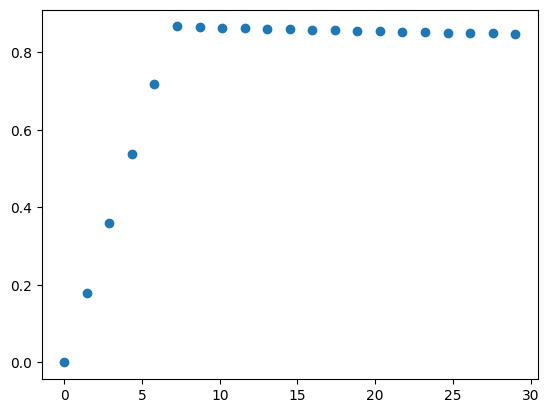

In [6]:
D = 7
X = 0
Y = 0

epsilon = 3e-5  # A tiny shift

#Z = np.linspace(0, 29, 21) + epsilon
Z = np.linspace(0, 29, 21) + epsilon

print(Z)

SIG = 1

XP_MIN= -1000
XP_MAX = 1000
YP_MIN = -1000
YP_MAX = 1000

Mod = potential_due_sheet(D, SIG, t_ox=12, t_sige=3)
V = np.empty((Z.shape[0]))
err = np.empty_like(V)
err =  np.empty((Z.shape[0]))

for i in range(Z.shape[0]):

    #V[i] = Mod.integrate_gfn_simps(X, Y, Z[i], XP_MIN, XP_MAX, YP_MIN, YP_MAX,1000)

    V[i], err[i] = Mod.integrate_greens_function(X, Y, Z[i], XP_MIN, XP_MAX, YP_MIN, YP_MAX)

    if i%3 == 0:

        print(i)

plt.scatter(Z, V)
np.save("potential_{}X{}_sheet_in_Front_of_conductor_no_counts.npy".format(XP_MAX, YP_MAX), V)

array([ 0.124,  0.124,  0.124,  0.124,  0.102, -0.001, -0.001, -0.001,
       -0.001, -0.001, -0.001, -0.001, -0.001, -0.001, -0.001, -0.001,
       -0.001, -0.001, -0.001, -0.001])

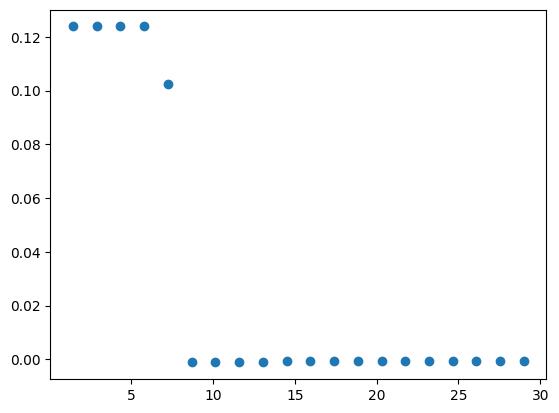

In [7]:
E = np.diff(V) / np.diff(Z)

plt.scatter(Z[1:], E)

np.round(E,3)

[3.000000e-05 1.450030e+00 2.900030e+00 4.350030e+00 5.800030e+00
 7.250030e+00 8.700030e+00 1.015003e+01 1.160003e+01 1.305003e+01
 1.450003e+01 1.595003e+01 1.740003e+01 1.885003e+01 2.030003e+01
 2.175003e+01 2.320003e+01 2.465003e+01 2.610003e+01 2.755003e+01
 2.900003e+01]
0


C:\Users\Vivrekar\AppData\Roaming\Python\Python312\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
C:\Users\Vivrekar\AppData\Roaming\Python\Python312\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


3
6
9
12
15
18


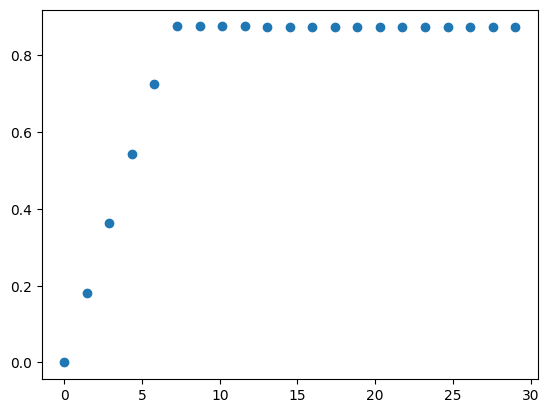

In [8]:
D = 7
X = 0
Y = 0

epsilon = 3e-5  # A tiny shift

#Z = np.linspace(0, 29, 21) + epsilon
Z = np.linspace(0, 29, 21) + epsilon

print(Z)

SIG = 1

XP_MIN= -np.inf
XP_MAX = np.inf
YP_MIN = -np.inf
YP_MAX = np.inf

Mod = potential_due_sheet(D, SIG, t_ox=12, t_sige=3)
V = np.empty((Z.shape[0]))
err = np.empty_like(V)
err =  np.empty((Z.shape[0]))

for i in range(Z.shape[0]):

    #V[i] = Mod.integrate_gfn_simps(X, Y, Z[i], XP_MIN, XP_MAX, YP_MIN, YP_MAX,1000)

    V[i], err[i] = Mod.integrate_greens_function(X, Y, Z[i], XP_MIN, XP_MAX, YP_MIN, YP_MAX)

    if i%3 == 0:

        print(i)

plt.scatter(Z, V)
np.save("potential_infXinf_sheet_in_Front_of_conductor_no_counts.npy", V)

array([ 0.125,  0.125,  0.125,  0.125,  0.103, -0.   , -0.   , -0.   ,
       -0.   ,  0.   , -0.   ,  0.   , -0.   ,  0.   ,  0.   ,  0.   ,
       -0.   ,  0.   , -0.   , -0.   ])

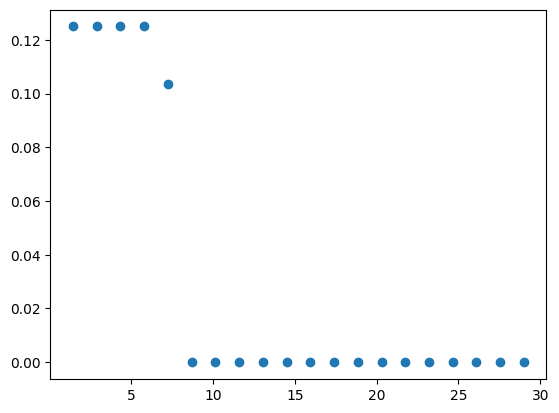

In [9]:
E = np.diff(V) / np.diff(Z)

plt.scatter(Z[1:], E)

np.round(E,3)

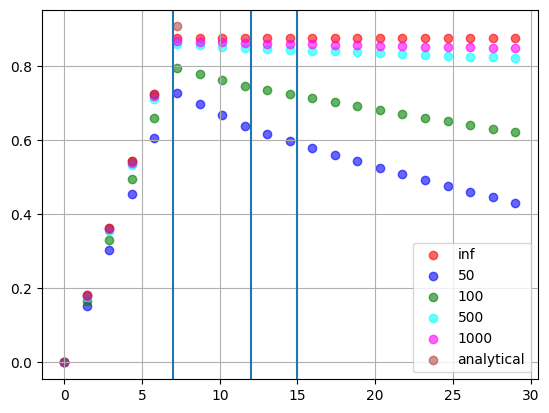

In [10]:
# Load your data (replace with actual loading mechanism)
array1 = np.load("potential_infXinf_sheet_in_Front_of_conductor_no_counts.npy")  # Example: 100 points (x, y)
array2 = np.load("potential_50X50_sheet_in_Front_of_conductor_no_counts.npy") 
array3 = np.load("potential_100X100_sheet_in_Front_of_conductor_no_counts.npy")
array4 = np.load("potential_500X500_sheet_in_Front_of_conductor_no_counts.npy")
array5 = np.load("potential_1000X1000_sheet_in_Front_of_conductor_no_counts.npy")

# Create scatter plots with different colors
plt.scatter(Z, array1, color='red', label='inf', alpha=0.6)
plt.scatter(Z, array2, color='blue', label='50', alpha=0.6)
plt.scatter(Z, array3, color='green', label='100', alpha=0.6)
plt.scatter(Z, array4, color='cyan', label='500', alpha=0.6)
plt.scatter(Z, array5, color='magenta', label='1000', alpha=0.6)

plt.axvline(x=7)
plt.axvline(x=12)
plt.axvline(x=15)

plt.scatter(Z[:6], Z[:6]/8, color='brown', label='analytical', alpha=0.5)

plt.legend()
plt.grid(True)

# Show plot
plt.show()

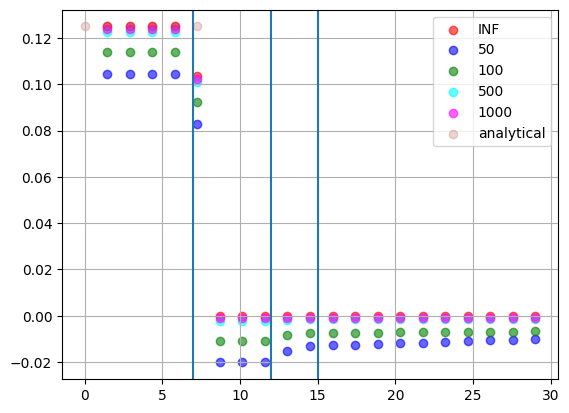

In [11]:
# Compute E = dV/dZ
E1 = np.diff(array1) / np.diff(Z)
E2 = np.diff(array2) / np.diff(Z)
E3 = np.diff(array3) / np.diff(Z)
E4 = np.diff(array4) / np.diff(Z)
E5 = np.diff(array5) / np.diff(Z)

# Create scatter plots with different colors
plt.scatter(Z[1:], E1, color='red', label='INF', alpha=0.6)
plt.scatter(Z[1:], E2, color='blue', label='50', alpha=0.6)
plt.scatter(Z[1:], E3, color='green', label='100', alpha=0.6)
plt.scatter(Z[1:], E4, color='cyan', label='500', alpha=0.6)
plt.scatter(Z[1:], E5, color='magenta', label='1000', alpha=0.6)

plt.scatter(Z[:6], np.ones_like(Z[:6])/8, color='brown', label='analytical', alpha=0.2)

plt.axvline(x=7)
plt.axvline(x=12)
plt.axvline(x=15)


plt.legend()
plt.grid(True)

# Show plot
plt.show()

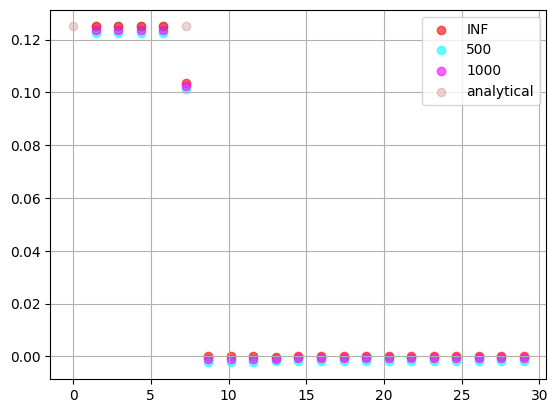

In [12]:
# Compute E = dV/dZ
E1 = np.diff(array1) / np.diff(Z)
E2 = np.diff(array2) / np.diff(Z)
E3 = np.diff(array3) / np.diff(Z)
E4 = np.diff(array4) / np.diff(Z)
E5 = np.diff(array5) / np.diff(Z)

# Create scatter plots with different colors
plt.scatter(Z[1:], E1, color='red', label='INF', alpha=0.6)
#plt.scatter(Z[:-1], E2, color='blue', label='50', alpha=0.6)
#plt.scatter(Z[:-1], E3, color='green', label='100', alpha=0.6)
plt.scatter(Z[1:], E4, color='cyan', label='500', alpha=0.6)
plt.scatter(Z[1:], E5, color='magenta', label='1000', alpha=0.6)

plt.scatter(Z[:6], np.ones_like(Z[:6])/8, color='brown', label='analytical', alpha=0.2)

plt.legend()
plt.grid(True)

# Show plot
plt.show()

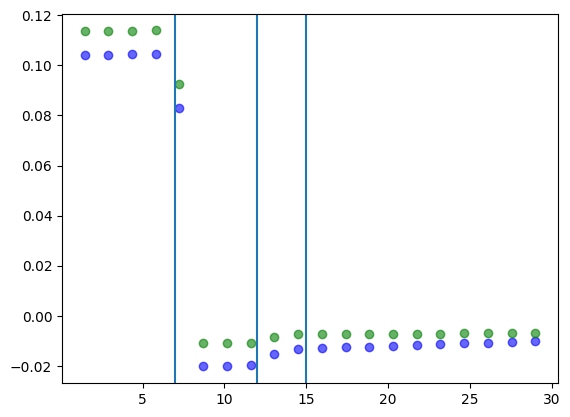

In [13]:
# Create scatter plots with different colors
#plt.scatter(Z[:-1], E1, color='red', label='INF', alpha=0.6)
plt.scatter(Z[1:], E2, color='blue', label='50', alpha=0.6)
plt.scatter(Z[1:], E3, color='green', label='100', alpha=0.6)

plt.axvline(x=7)
plt.axvline(x=12)
plt.axvline(x=15)
